In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('gaming_mental_health_10M_40features.csv')
df = pd.DataFrame(data)
df.shape

(1000000, 39)

Проверим пропуски и дубликаты


In [5]:
print(df.isnull().sum().sum())
print(df.duplicated().sum())

0
0


In [6]:
df.head()

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [7]:
df.describe()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,35.986005,77497.675955,3.999255,19.997540,12.002512,7.00053,1.997513,1.999008,5.497577,4.998644,...,4.996374,4.998520,5.000455,5.981822,24.003916,8.002032,4.998675,4.018777,49.448122,5.503339
std,13.557163,41851.540503,2.826307,11.253438,7.207838,1.50111,1.996174,1.999545,2.873248,1.977711,...,3.160810,1.977601,1.980307,1.956122,3.999927,3.998987,1.979308,1.956123,28.873153,2.871940
min,13.000000,5000.000000,0.000000,1.000000,0.000000,-0.17000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.450000,0.070000,0.000000,0.000000,0.000000,1.000000
25%,24.000000,41258.000000,1.920000,10.000000,6.000000,5.99000,0.580000,0.580000,3.000000,3.650000,...,2.000000,3.650000,3.650000,4.650000,21.300000,5.070000,3.650000,2.660000,24.000000,3.000000
50%,36.000000,77521.000000,3.360000,20.000000,12.000000,7.00000,1.390000,1.390000,5.000000,5.000000,...,5.000000,5.000000,5.000000,6.000000,24.000000,7.350000,5.000000,4.000000,49.000000,6.000000
75%,48.000000,113697.000000,5.380000,30.000000,18.000000,8.01000,2.770000,2.770000,8.000000,6.350000,...,8.000000,6.350000,6.350000,7.350000,26.700000,10.220000,6.350000,5.350000,74.000000,8.000000
max,59.000000,149999.000000,30.420000,39.000000,24.000000,14.02000,26.900000,26.480000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,43.600000,46.600000,10.000000,10.000000,99.000000,10.000000


In [8]:
df['gender'].value_counts()

,count
gender,
Male,480581
Female,479579
Other,39840


Удалим данные с гендером Other

In [9]:
df = df[~df.isin(['Other']).any(axis=1)]
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [10]:
df['gender'].value_counts()

,count
gender,
0,480581
1,479579


Посмотрим какие признаки наиболее важны

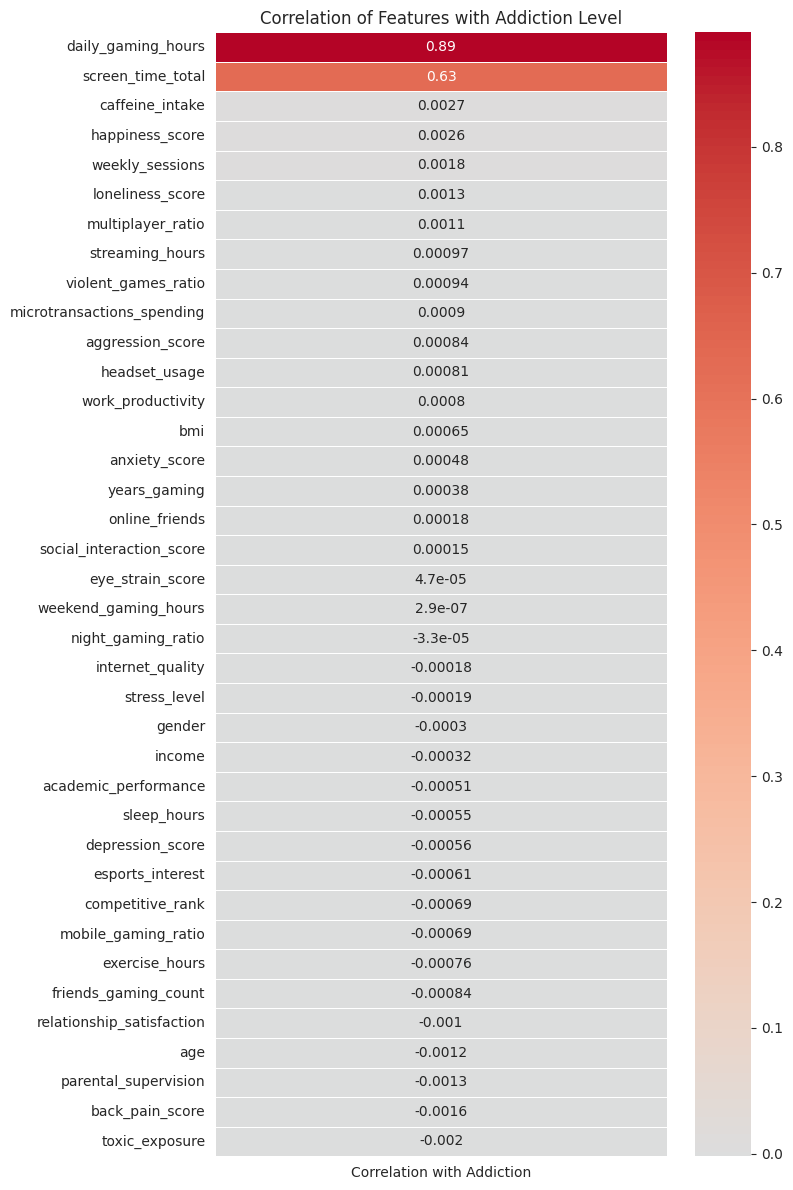

In [11]:
sns.set_style("darkgrid")

numeric_df = df.select_dtypes(include="number")
corr_target = numeric_df.corr()["addiction_level"].sort_values(ascending=False)
corr_target = corr_target.drop("addiction_level")
corr_df = corr_target.to_frame(name="Correlation with Addiction")
plt.figure(figsize=(8, 12))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation of Features with Addiction Level")
plt.tight_layout()
plt.show()

Оставляем только необходимые признаки

In [12]:
top_features = ['daily_gaming_hours', 'screen_time_total', 'caffeine_intake', 'happiness_score', 'weekly_sessions', 'loneliness_score', 'addiction_level', 'age', 'gender']
df = df[top_features]

Создание целевой переменной 'addiction_risk'

Распределение целевой переменной:
   LOW_RISK  (0): 721,187 (75.11%)
   HIGH_RISK (1): 238,973 (24.89%)


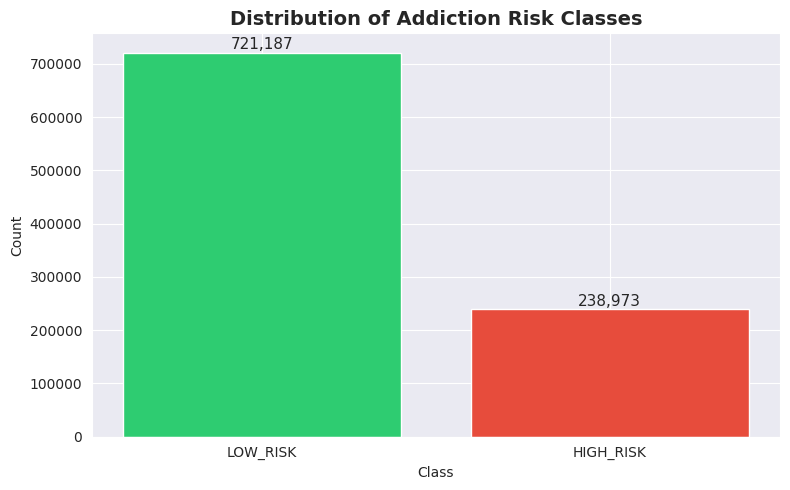

In [13]:
print("Создание целевой переменной 'addiction_risk'")

ADDICTION_THRESHOLD = 4.0

df['addiction_risk'] = (
    df['addiction_level'] >= ADDICTION_THRESHOLD
).astype(int)


risk_dist = df['addiction_risk'].value_counts()
risk_pct = (risk_dist / len(df) * 100).round(2)

print(f"\nРаспределение целевой переменной:")
print(f"   LOW_RISK  (0): {risk_dist.get(0, 0):,} ({risk_pct.get(0, 0):.2f}%)")
print(f"   HIGH_RISK (1): {risk_dist.get(1, 0):,} ({risk_pct.get(1, 0):.2f}%)")

plt.figure(figsize=(8, 5))
bars = plt.bar(['LOW_RISK', 'HIGH_RISK'], risk_dist.values, color=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Addiction Risk Classes', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Class')


for bar, val in zip(bars, risk_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [14]:
df['addiction_risk'].describe()

,addiction_risk
count,960160.000000
mean,0.248889
std,0.432369
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


Выберем наиболее важные признаки

In [15]:
X = df.drop(['addiction_risk', 'addiction_level'], axis=1, errors='ignore')
y = df['addiction_risk']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.45,
    stratify=y,
    random_state=42,
    shuffle=True
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (528088, 8), Test: (432072, 8)
Распределение классов в train: {0: 396653, 1: 131435}


In [ ]:
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
X_test_df.to_csv('X_test_data.csv', index=False)
print('Saved X_test_data.csv')

Saved X_test_data.csv


Обучение Logistic Regression

In [18]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=0.1,
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, lr_pred, target_names=['LOW_RISK', 'HIGH_RISK']))


              precision    recall  f1-score   support

    LOW_RISK       0.96      0.88      0.92    324534
   HIGH_RISK       0.71      0.88      0.79    107538

    accuracy                           0.88    432072
   macro avg       0.83      0.88      0.85    432072
weighted avg       0.90      0.88      0.88    432072



In [19]:
lr_artifacts = {
    'model': lr_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'model_type': 'LogisticRegression',
    'threshold': ADDICTION_THRESHOLD
}
joblib.dump(lr_artifacts, 'model_Logistic_Regression.joblib', compress=3)
print("Saved: model_Logistic_Regression.joblib")

Saved: model_Logistic_Regression.joblib


Обучение Gradient Boosting

In [20]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    min_samples_split=50,
    min_samples_leaf=20
)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
gb_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, gb_pred, target_names=['LOW_RISK', 'HIGH_RISK']))


              precision    recall  f1-score   support

    LOW_RISK       0.92      0.95      0.94    324534
   HIGH_RISK       0.84      0.75      0.79    107538

    accuracy                           0.90    432072
   macro avg       0.88      0.85      0.87    432072
weighted avg       0.90      0.90      0.90    432072



In [21]:
gb_artifacts = {
    'model': gb_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'model_type': 'GradientBoosting',
    'threshold': ADDICTION_THRESHOLD
}
joblib.dump(gb_artifacts, 'model_Gradient_Boosting.joblib', compress=3)
print("Saved: model_Gradient_Boosting.joblib")

Saved: model_Gradient_Boosting.joblib


In [22]:
def calculate_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)

    }

lr_metrics = calculate_metrics(y_test, lr_pred, lr_pred_proba)
gb_metrics = calculate_metrics(y_test, gb_pred, gb_pred_proba)

metrics_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Gradient Boosting': gb_metrics
})

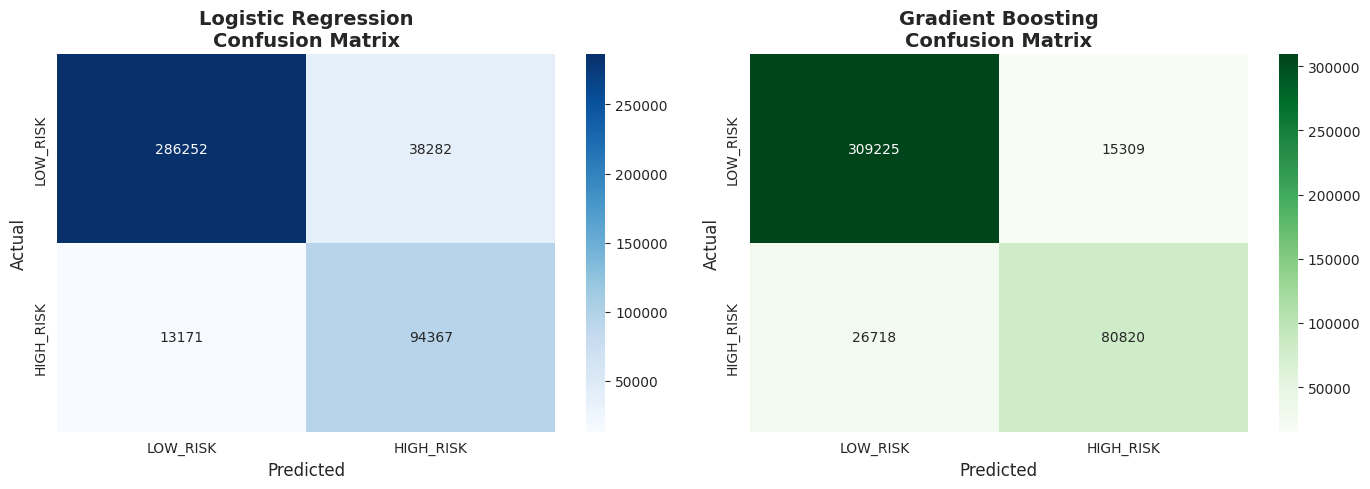

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['LOW_RISK', 'HIGH_RISK'],
            yticklabels=['LOW_RISK', 'HIGH_RISK'])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Gradient Boosting
cm_gb = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['LOW_RISK', 'HIGH_RISK'],
            yticklabels=['LOW_RISK', 'HIGH_RISK'])
axes[1].set_title('Gradient Boosting\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


ГРАФИК СРАВНЕНИЯ МЕТРИК


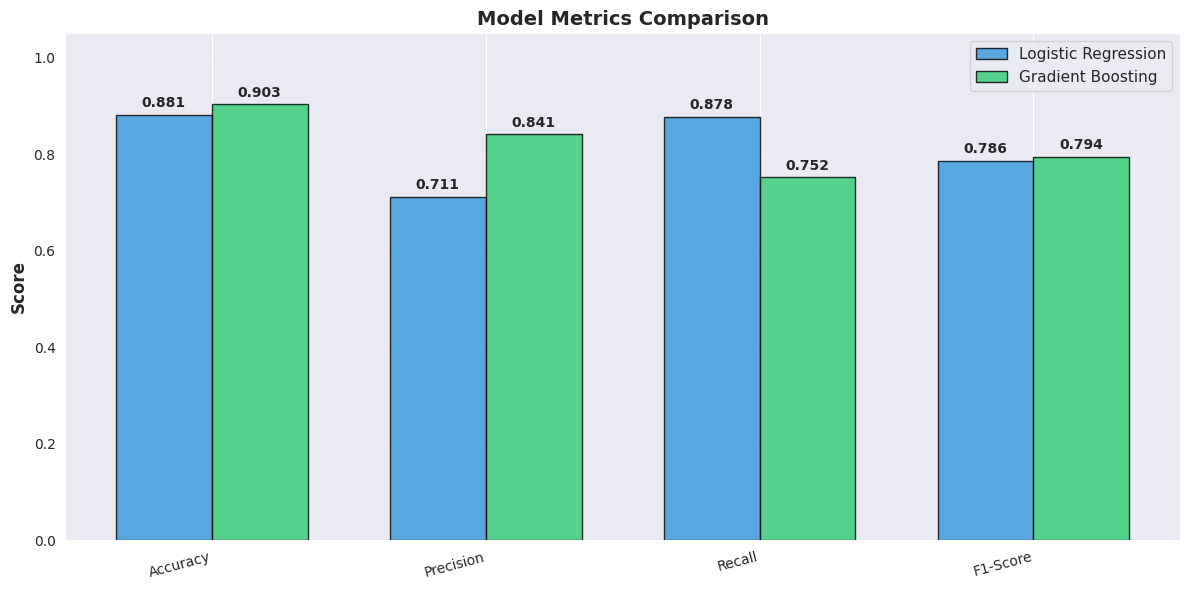

In [25]:
print("\n" + "="*60)
print("ГРАФИК СРАВНЕНИЯ МЕТРИК")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = list(lr_metrics.keys())
x = np.arange(len(metrics_names))
width = 0.35

lr_values = [lr_metrics[m] for m in metrics_names]
gb_values = [gb_metrics[m] for m in metrics_names]

bars1 = ax.bar(x - width/2, lr_values, width, label='Logistic Regression',
               color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, gb_values, width, label='Gradient Boosting',
               color='#2ecc71', alpha=0.8, edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars1, lr_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, gb_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Выборем логистическую регрессию, так как она чаще выявляет игроков с игровой зависимостью.Даже если она ошибается, лучше предупредить человека, что у него высокий риск игровой зависимости, чтобы он пересмотрел своё количество игровых часов